In [7]:
import pandas as pd

# Nome do ficheiro gerado pelo script de benchmark
FILE_PATH = "benchmark_multi_dqn.csv"

def gerar_medias():
    try:
        # 1. Carregar o CSV
        df = pd.read_csv(FILE_PATH)

        print(f"Dados carregados: {len(df)} episódios encontrados.")

        # 2. Selecionar apenas colunas numéricas para a média
        # Mantemos 'Agente' como índice do agrupamento
        colunas_metricas = [
            'Acurácia',
            'Sensibilidade (Dengue)',
            'Especificidade',
            'F1-Score',
            'Custo Total de Testes',
            'Custo por Acerto',
            'Redução de Testes (%)'
        ]

        # Verificar se as colunas existem antes de processar
        cols_existentes = [c for c in colunas_metricas if c in df.columns]

        # 3. Agrupar por Agente e calcular Média e Desvio Padrão
        # O 'numeric_only=True' garante que não tentamos fazer média de texto
        summary_mean = df.groupby('Agente')[cols_existentes].mean()
        summary_std = df.groupby('Agente')[cols_existentes].std()

        # 4. Exibir no Console (Formatado)
        print("\n" + "="*60)
        print("TABELA DE MÉDIAS (Para o TCC)")
        print("="*60)
        print(summary_mean.round(4)) # Arredonda para 4 casas decimais

        # 5. Salvar em Excel ou CSV limpo para copiar/colar
        summary_mean.to_csv("tabela_medias_final.csv")
        summary_std.to_csv("tabela_desvio_padrao.csv")

        print("\nArquivos 'tabela_medias_final.csv' e 'tabela_desvio_padrao.csv' foram salvos!")

    except FileNotFoundError:
        print(f"ERRO: O ficheiro '{FILE_PATH}' não foi encontrado.")
        print("Certifique-se de ter rodado o 'COMPARACAO.py' antes.")
    except Exception as e:
        print(f"Ocorreu um erro inesperado: {e}")



In [8]:
gerar_medias()

Dados carregados: 30 episódios encontrados.

TABELA DE MÉDIAS (Para o TCC)
            Acurácia  Sensibilidade (Dengue)  Especificidade  F1-Score  \
Agente                                                                   
Aleatório     0.7089                  0.7086          0.7093    0.7086   
DQN           0.7129                  0.7200          0.7057    0.7141   
Q-Learning    0.7064                  0.7093          0.7036    0.7082   

            Custo Total de Testes  Custo por Acerto  Redução de Testes (%)  
Agente                                                                      
Aleatório                    96.4            0.5049                82.7857  
DQN                          39.0            0.1742                93.0357  
Q-Learning                  182.1            0.9566                67.4821  

Arquivos 'tabela_medias_final.csv' e 'tabela_desvio_padrao.csv' foram salvos!


Inicializando ambiente e gerando epidemia...
Mapa salvo em: mapa_epidemia.png
Concluído.


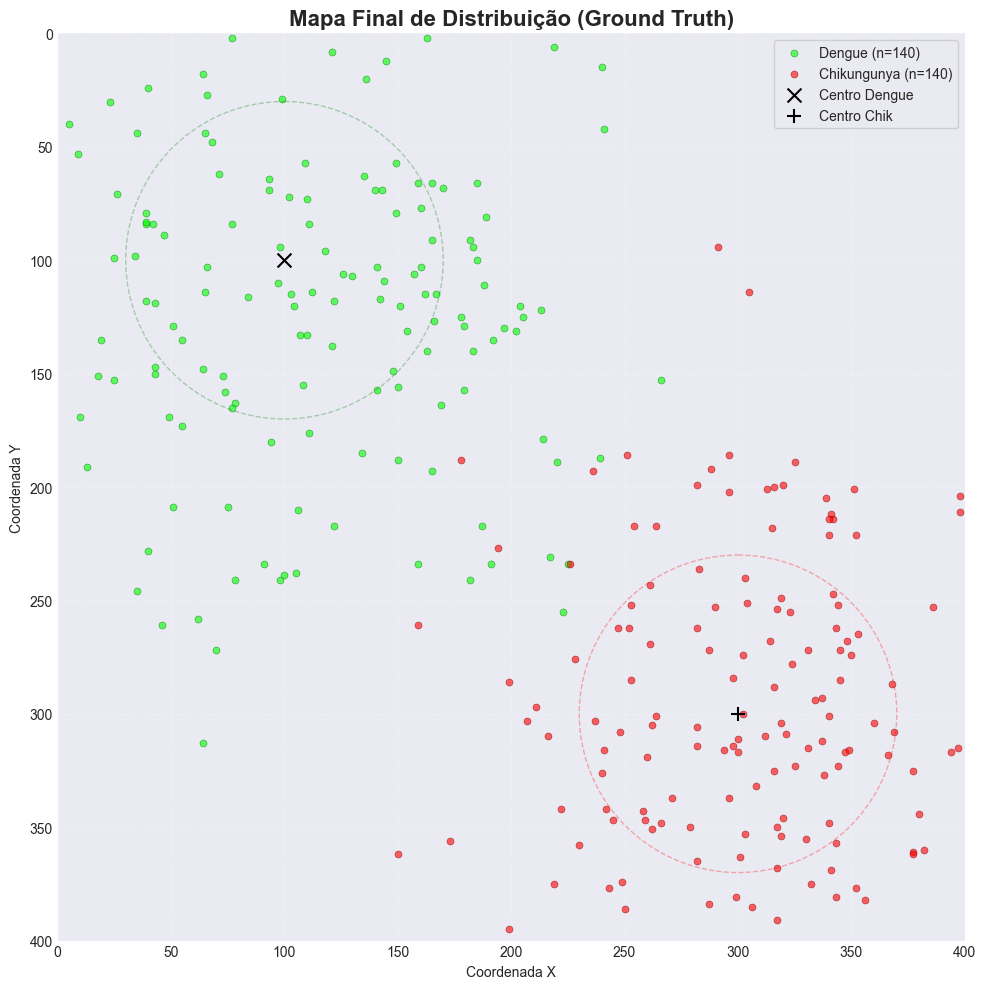

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from dengue_envs.envs.dengue_diagnostics import DengueDiagnosticsEnv

def plot_final_epidemic(env, title="Mapa Final de Distribuição (Ground Truth)", save_path="mapa_epidemia.png"):
    """
    Plota a distribuição espacial de TODOS os casos da epidemia simulada.
    Usa o dataframe interno do mundo (env.world.casedf) que contém a "verdade"
    de todos os casos gerados pelo modelo SIR.
    """
    # Acessa o DataFrame com o histórico completo da simulação
    # Como o mundo é pré-gerado, isso contém todos os casos do dia 0 ao fim.
    df = env.world.casedf

    if df is None or df.empty:
        print("Erro: DataFrame de casos vazio. O ambiente foi resetado?")
        return

    # Filtra por doença (0: Dengue, 1: Chikungunya)
    dengue_cases = df[df['disease'] == 0]
    chik_cases = df[df['disease'] == 1]

    # --- Configuração do Plot ---
    # Usar um estilo limpo ou escuro para contraste
    try:
        plt.style.use('seaborn-v0_8-darkgrid')
    except:
        plt.style.use('ggplot') # Fallback se seaborn não estiver instalado

    fig, ax = plt.subplots(figsize=(10, 10))

    # 1. Plotar Dengue (Verde)
    ax.scatter(
        dengue_cases['x'],
        dengue_cases['y'],
        c='#00FF00',        # Verde Brilhante (Lime Green)
        label=f'Dengue (n={len(dengue_cases)})',
        alpha=0.6,          # Transparência para ver sobreposição (densidade)
        s=25,               # Tamanho do ponto
        edgecolors='green', # Borda um pouco mais escura para definição
        linewidth=0.5
    )

    # 2. Plotar Chikungunya (Vermelho)
    ax.scatter(
        chik_cases['x'],
        chik_cases['y'],
        c='#FF0000',        # Vermelho Puro
        label=f'Chikungunya (n={len(chik_cases)})',
        alpha=0.6,
        s=25,
        edgecolors='darkred',
        linewidth=0.5
    )

    # 3. Desenhar os Centros (Focos) para referência
    # O ambiente guarda os centros usados na geração
    if hasattr(env, 'dengue_center'):
        ax.scatter(*env.dengue_center, c='black', marker='x', s=100, label='Centro Dengue', zorder=10)
        # Círculo indicativo do raio aproximado
        circle_d = plt.Circle(env.dengue_center, env.dengue_radius, color='green', fill=False, linestyle='--', alpha=0.3)
        ax.add_patch(circle_d)

    if hasattr(env, 'chik_center'):
        ax.scatter(*env.chik_center, c='black', marker='+', s=100, label='Centro Chik', zorder=10)
        circle_c = plt.Circle(env.chik_center, env.chik_radius, color='red', fill=False, linestyle='--', alpha=0.3)
        ax.add_patch(circle_c)

    # --- Estética ---
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel("Coordenada X")
    ax.set_ylabel("Coordenada Y")

    # IMPORTANTE: Inverter eixo Y para corresponder à matriz/Pygame
    # (No Pygame, (0,0) é topo-esquerda. No plot padrão, é baixo-esquerda)
    ax.set_ylim(env.size, 0)
    ax.set_xlim(0, env.size)
    ax.set_aspect('equal') # Garante que o mapa não fique distorcido

    ax.legend(loc='upper right', frameon=True, framealpha=0.9)
    ax.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()

    # Salvar e Mostrar
    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"Mapa salvo em: {save_path}")

plt.show()

# Exemplo de uso
print("Inicializando ambiente e gerando epidemia...")

# Configurações para gerar uma epidemia interessante visualmente
env = DengueDiagnosticsEnv(
    size=400,
    epilength=60,
    dengue_radius=70, # Raios maiores espalham mais
    chik_radius=70
)

# O reset garante a criação dos dados
env.reset(seed=42)

# Chama a função de plotagem
plot_final_epidemic(env)

print("Concluído.")